# 📊 Advanced Parallel Scaling Laws: Amdahl, Gustafson, Strong, and Weak Scaling

This document explains the core mathematical concepts behind how parallel computing scales, covering Amdahl's Law, Gustafson's Law, Strong Scaling, and Weak Scaling.

---

## 📐 1. Amdahl's Law (The Limit of Speedup)

Amdahl's Law addresses **how much faster a fixed problem can run** if we add more processors ($P$). It focuses on the *inherent limitation* imposed by the serial portion of the code.

### The Setup
A task is divided into two parts:
1.  **Serial Fraction ($\alpha$):** The portion of the code that *must* run on one processor.
2.  **Parallel Fraction ($1-\alpha$):** The portion that *can* be split across multiple processors.

### The Formula
The theoretical speedup ($S$) achieved when using $P$ processors is given by:

$$
S_{\text{Amdahl}} = \frac{1}{\alpha + \frac{(1 - \alpha)}{P}}
$$

### Interpretation
*   **The Ceiling:** As $P$ approaches infinity, the speedup approaches a limit: $\frac{1}{(1 - \alpha)}$.
*   **Example:** If $\alpha = 0.1$ (10% serial), the maximum speedup is $1/(1-0.1) = 1/0.9 \approx 1.11x$. No matter how many cores you add, the speedup will never exceed 1.11x.

---

## 📈 2. Gustafson's Law (The Power of Scaling)

Gustafson's Law (or Scalability Law) challenges Amdahl's Law. It asks: **If we have more processors, can we solve a *larger* problem in the *same* amount of time?** It assumes the problem size scales with the number of processors.

### The Setup
We fix the total execution time ($T$) and see how large the problem size ($W$) can become.

### The Formula
The speedup ($S$) is defined relative to the time taken on a single processor ($T_1$). When the problem is scaled, the speedup is often expressed as the ratio of the *scaled problem size* to the original problem size.

For a fixed time $T$, the scaled problem size solved is:
$$
W_{\text{scaled}} = W_{\text{original}} \times S_{\text{Gustafson}}
$$
Where:
$$
S_{\text{Gustafson}} = (1 - \alpha) + (\alpha \cdot P)
$$

### Interpretation
Gustafson's Law shows that as $P$ increases, the potential speedup increases **linearly**, because you are not constrained by a fixed problem size; you are allowed to increase the work to keep all processors busy.

---

## 📉 3. Strong Scaling (Fixed Problem Size)

Strong Scaling focuses on **keeping the problem size constant** and measuring how much faster you can solve it by adding more processors.

*   **Goal:** To achieve the highest possible speedup for a fixed input.
*   **Constraint:** $\text{Input Size} = \text{Constant}$
*   **Governed By:** Amdahl's Law. The speedup gain will eventually flatten out as the serial portion becomes the bottleneck.

---

## 🌊 4. Weak Scaling (Fixed Time Budget)

Weak Scaling focuses on **keeping the execution time constant** and measuring how large the problem can become by adding more processors.

*   **Goal:** To keep the runtime constant as the system scales up.
*   **Constraint:** $\text{Time} = \text{Constant}$
*   **Governed By:** Gustafson's Law. You add more data ($\text{Input Size} \propto P$) to keep the workload per core consistent, allowing the runtime to remain stable.

---

# 🐍 Python Parallelism
To implement parallel code in Python we can use several libraries, in this case we will use `multiprocessing`.

---

## 🚀 Concurrency vs. Parallelism

It is essential to define these terms first:

*   **Concurrency:** The *ability* to handle multiple tasks seemingly at the same time by rapidly switching between them (context switching). This is best for **I/O-Bound Tasks** (tasks waiting for external resources like network responses or disk reads).
    *   *Python Tools:* `threading`, `asyncio`.
*   **Parallelism:** The actual execution of multiple tasks *simultaneously* by utilizing multiple physical CPU cores. This is necessary for **CPU-Bound Tasks** (tasks that require heavy computation, like complex math).
    *   *Python Tools:* `multiprocessing`, `joblib`.

---

## 🛠️ The `multiprocessing` Library

The `multiprocessing` module is Python's native way to achieve true parallelism.

**How it works:**
It achieves parallelism by spawning entirely separate **Operating System (OS) Processes**. Because each process has its own isolated memory space and interpreter, they do not contend for the Global Interpreter Lock (GIL).

**Pros:**
*   Guarantees true parallelism on multi-core CPUs.
*   Part of the Python standard library (no installation needed).

**Cons:**
*   **High Overhead:** Creating a new OS process is resource-intensive.
*   **Serialization Cost:** Data must be "pickled" (serialized) to be sent from the parent process to the child process, and the results must be un-pickled upon return. This communication overhead can negate gains if the task is too small.


In [1]:
# Setup simulation
import time
import multiprocessing as mp
import random
import math
import matplotlib.pyplot as plt
import numpy as np

## Strong Scaling 

In [2]:
# --- Configuration for Strong Scaling measurments ---
# The total amount of work (e.g., number of items to process)
TOTAL_WORK = 16_000_000
# The fraction of the work that MUST run serially (0.0 to 1.0)
# We will test different values of this!
SERIAL_FRACTION = 0.2  # Example: 20% serial, 80% parallel

print(f"Configuration Set:")
print(f"Total Work Units: {TOTAL_WORK}")
print(f"Serial Fraction (alpha): {SERIAL_FRACTION}")

# --- Worker Function ---
def process_chunk(chunk_data):
    """Simulates a unit of parallelizable work."""
    # Simulate computation time (e.g., CPU-bound task)
    # Using random sleep/calculation to mimic real-world variance
    time.sleep(random.uniform(0.00001, 0.00005)) 
    return sum(chunk_data)

def serial_task(serial_work):
    """Simulates the serial portion of the task."""
    # Simulates the fixed overhead/serial component
    return sum(range(serial_work))


Configuration Set:
Total Work Units: 16000000
Serial Fraction (alpha): 0.2


In [3]:
def measure_parallel_time_mp(num_processes, workload, serial_fraction):
    serial_work = int(workload * serial_fraction)
    parallel_work = int(workload * (1-serial_fraction))
    
    start_time = time.perf_counter()

    # Serial phase
    serial_result = serial_task(serial_work)

    # Parallel phase
    chunk_size = math.ceil(parallel_work / num_processes)

    chunks = [
        range(i, min(i + chunk_size, parallel_work))
        for i in range(0, parallel_work, chunk_size)
    ]

    with mp.Pool(processes=num_processes) as pool:
        results = pool.map(process_chunk, chunks)

    parallel_result = sum(results)

    end_time = time.perf_counter()

    return end_time - start_time

In [4]:
import numpy as np
# (Assume all other necessary imports and setup functions like measure_parallel_time_mp are available)

# --- Configuration ---
P_values = [1, 2, 4, 8, 16] # Test runs for 1, 2, 4, 8, 16 cores
NUM_REPETITIONS = 5

# results storage: Now uses NumPy arrays for vectors
# Initialize storage structure
results = {
    i: {"parallel_times": None, "speedup_vector": None} 
    for i in P_values
}

print("--- Starting Performance Measurement (5 Repetitions per Core Count using NumPy) ---")

# ======================================================================
# STEP 1: Handle P=1 (Baseline Serial Time)
# ======================================================================
P1_measurements = []
print("\n--- Measuring Baseline (P=1) ---")
for _ in range(NUM_REPETITIONS):
    # Must call the function for P=1 to get the baseline time
    time_p1 = measure_parallel_time_mp(1, TOTAL_WORK, SERIAL_FRACTION) 
    P1_measurements.append(time_p1)

baseline = np.array(P1_measurements)
results[1]["parallel_times"] = baseline
results[1]["speedup_vector"] = baseline / baseline.mean()

# Calculate the average baseline time (Reference Time)
avg_p1_time = np.mean(baseline) 
print(f"[Baseline] Average Time (P=1): {avg_p1_time:.4f} seconds")

# ======================================================================
# STEP 2: Test P > 1 and store vectors using NumPy
# ======================================================================
print("\n--- Measuring Parallel Runs ---")
for P in P_values:
    if P == 1:
        continue
        
    # Initialize NumPy arrays to hold the 5 results for this P
    current_p_times_vector = np.zeros(NUM_REPETITIONS)
    speedup_vector = np.zeros(NUM_REPETITIONS)
    
    for rep in range(NUM_REPETITIONS):
        # Measure time for the current core count (P)
        parallel_time = measure_parallel_time_mp(P, TOTAL_WORK, SERIAL_FRACTION)
        
        # Store time in the NumPy array (assignment, not append)
        current_p_times_vector[rep] = parallel_time
        
        # Calculate speedup for THIS repetition
        speedup = avg_p1_time / parallel_time
        speedup_vector[rep] = speedup
        
    # Store the resulting NumPy vectors
    results[P]['parallel_times'] = current_p_times_vector
    results[P]['speedup_vector'] = speedup_vector
    
    # Logging the average speedup for immediate feedback using NumPy mean()
    avg_speedup = np.mean(speedup_vector)
    
    print(f"P={P:2}: Average Time={np.mean(current_p_times_vector):.4f}s, Avg Speedup={avg_speedup:.2f}x")

print("\n--- Measurement Complete ---")

# Optional: Display the structure of the final results using NumPy arrays
print("\n--- Final Results Structure Check ---")
for P in P_values:
    print(f"Results for P={P}:")
    print(f"  Time Vector Shape: {results[P]['parallel_times'].shape}")
    print(f"  Speedup Vector Shape: {results[P]['speedup_vector'].shape}")

--- Starting Performance Measurement (5 Repetitions per Core Count using NumPy) ---

--- Measuring Baseline (P=1) ---
[Baseline] Average Time (P=1): 0.2237 seconds

--- Measuring Parallel Runs ---
P= 2: Average Time=0.1405s, Avg Speedup=1.62x
P= 4: Average Time=0.1055s, Avg Speedup=2.14x
P= 8: Average Time=0.1095s, Avg Speedup=2.05x
P=16: Average Time=0.1375s, Avg Speedup=1.63x

--- Measurement Complete ---

--- Final Results Structure Check ---
Results for P=1:
  Time Vector Shape: (5,)
  Speedup Vector Shape: (5,)
Results for P=2:
  Time Vector Shape: (5,)
  Speedup Vector Shape: (5,)
Results for P=4:
  Time Vector Shape: (5,)
  Speedup Vector Shape: (5,)
Results for P=8:
  Time Vector Shape: (5,)
  Speedup Vector Shape: (5,)
Results for P=16:
  Time Vector Shape: (5,)
  Speedup Vector Shape: (5,)


In [5]:
def calculate_amdhahl(P, alpha):
    """Calculates Amdahl's Law Speedup for a fixed problem size."""
    if P <= 1: return 1.0
    return 1 / (alpha + ((1-alpha) / P))

# Store theoretical results
theo_amdahl = {}

for P in P_values:    
    # Amdahl's Law (Fixed Problem Size)
    a_speedup = calculate_amdhahl(P, SERIAL_FRACTION)
    theo_amdahl[P] = a_speedup

# Combine all data for plotting
plot_data = {}
for P in P_values:
    plot_data[P] = {
        'measured_speedup_mean': results[P]['speedup_vector'].mean(),
        'measured_speedup_std': results[P]['speedup_vector'].std(),
        'theo_amdahl': theo_amdahl[P],
    }

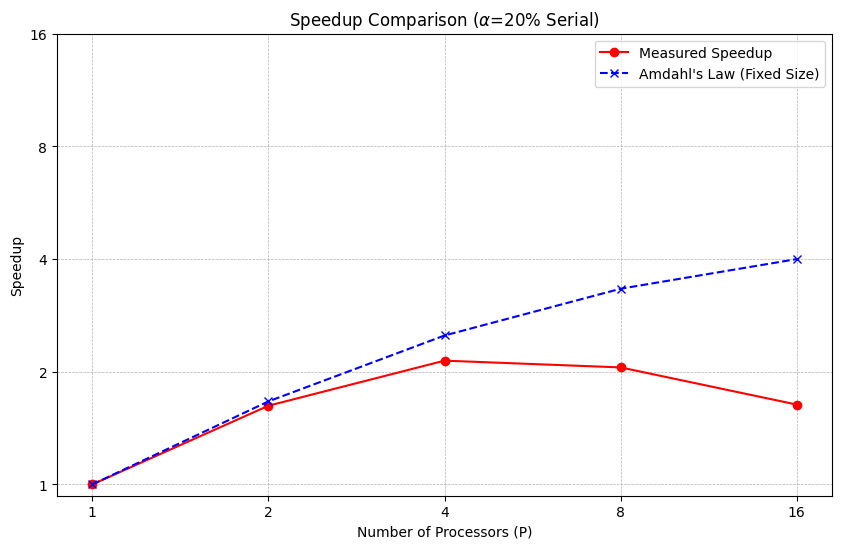

In [6]:
# Prepare data lists for plotting
P_list = list(plot_data.keys())
measured_speedups = [plot_data[P]['measured_speedup_mean'] for P in P_list]
amdhahl_speedups = [plot_data[P]['theo_amdahl'] for P in P_list]

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Plot 1: Speedup Comparison
plt.plot(P_list, measured_speedups, 'o-', label='Measured Speedup', color='red')
plt.plot(P_list, amdhahl_speedups, 'x--', label="Amdahl's Law (Fixed Size)", color='blue')

plt.title(f'Speedup Comparison ($\\alpha$={SERIAL_FRACTION*100:.0f}% Serial)')
plt.xlabel('Number of Processors (P)')
plt.ylabel('Speedup')
plt.yscale("log", base=2)
plt.xscale("log", base=2)
plt.xticks(P_values, [str(x) for x in P_values])
plt.yticks(P_values, [str(x) for x in P_values])
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## Weak scaling 

In [14]:
import numpy as np

# ============================================================
# Configuration
# ============================================================

P_values = [1, 2, 4, 8, 16]
NUM_REPETITIONS = 5

# constant workload PER PROCESS
WORKLOAD_PER_PROC = 1_000_000

results = {
    P: {
        "global_workload": None,
        "parallel_times": None,
        "weak_efficiency_vector": None,
    }
    for P in P_values
}

print("--- Starting Weak Scaling Benchmark ---")

# ============================================================
# STEP 1: Baseline (P=1)
# ============================================================

print("\n--- Measuring Baseline (P=1) ---")

baseline_workload = WORKLOAD_PER_PROC

P1_measurements = []

for _ in range(NUM_REPETITIONS):

    time_p1 = measure_parallel_time_mp(
        P,
        workload=baseline_workload,
        serial_fraction=SERIAL_FRACTION
    )

    P1_measurements.append(time_p1)

baseline = np.array(P1_measurements)

results[1]["global_workload"] = baseline_workload
results[1]["parallel_times"] = baseline
results[1]["weak_efficiency_vector"] = baseline / baseline.mean()

avg_p1_time = np.mean(baseline)

print(f"[Baseline] Avg Time: {avg_p1_time:.4f} s")

# ============================================================
# STEP 2: Weak Scaling Runs
# ============================================================

print("\n--- Measuring Weak Scaling Runs ---")

for P in P_values:

    if P == 1:
        continue

    # scale workload with process count
    global_workload = WORKLOAD_PER_PROC * P

    current_p_times_vector = np.zeros(NUM_REPETITIONS)
    weak_eff_vector = np.zeros(NUM_REPETITIONS)

    for rep in range(NUM_REPETITIONS):

        parallel_time = measure_parallel_time_mp(
            P,
            workload=global_workload,
            serial_fraction=SERIAL_FRACTION
        )

        current_p_times_vector[rep] = parallel_time

        # weak scaling efficiency
        weak_eff = avg_p1_time / parallel_time

        weak_eff_vector[rep] = weak_eff

    results[P]["global_workload"] = global_workload
    results[P]["parallel_times"] = current_p_times_vector
    results[P]["weak_efficiency_vector"] = weak_eff_vector

    print(
        f"P={P:2d} | "
        f"Workload={global_workload} | "
        f"Avg Time={np.mean(current_p_times_vector):.4f}s | "
        f"Weak Efficiency={np.mean(weak_eff_vector):.3f}"
    )

print("\n--- Weak Scaling Benchmark Complete ---")

# ============================================================
# Optional Structure Check
# ============================================================

print("\n--- Results Structure Check ---")

for P in P_values:

    print(f"\nP={P}")

    print(f"  Global workload: {results[P]['global_workload']}")
    print(f"  Time vector shape: {results[P]['parallel_times'].shape}")
    print(f"  Efficiency vector shape: {results[P]['weak_efficiency_vector'].shape}")

--- Starting Weak Scaling Benchmark ---

--- Measuring Baseline (P=1) ---
[Baseline] Avg Time: 0.1042 s

--- Measuring Weak Scaling Runs ---
P= 2 | Workload=2000000 | Avg Time=0.0298s | Weak Efficiency=3.541
P= 4 | Workload=4000000 | Avg Time=0.0763s | Weak Efficiency=1.414
P= 8 | Workload=8000000 | Avg Time=0.1100s | Weak Efficiency=1.010
P=16 | Workload=16000000 | Avg Time=0.2121s | Weak Efficiency=0.522

--- Weak Scaling Benchmark Complete ---

--- Results Structure Check ---

P=1
  Global workload: 1000000
  Time vector shape: (5,)
  Efficiency vector shape: (5,)

P=2
  Global workload: 2000000
  Time vector shape: (5,)
  Efficiency vector shape: (5,)

P=4
  Global workload: 4000000
  Time vector shape: (5,)
  Efficiency vector shape: (5,)

P=8
  Global workload: 8000000
  Time vector shape: (5,)
  Efficiency vector shape: (5,)

P=16
  Global workload: 16000000
  Time vector shape: (5,)
  Efficiency vector shape: (5,)


In [15]:
def calculate_gustafson(P, alpha):
    """
    Gustafson's Law
    alpha = serial fraction
    """
    if P <= 1:
        return 1.0

    return alpha + P*(1-alpha)

# Store theoretical results
theo_gustafson = {}

for P in P_values:    
    # Gustafson's Law (Fixed Problem load)
    g_speedup = calculate_gustafson(P, SERIAL_FRACTION)
    theo_gustafson[P] = g_speedup

# Combine all data for plotting
plot_data = {}
for P in P_values:
    plot_data[P] = {
        'measured_we_mean': results[P]['weak_efficiency_vector'].mean(),
        'measured_we_std': results[P]['weak_efficiency_vector'].std(),
        'theo_gustafson': theo_gustafson[P],
    }

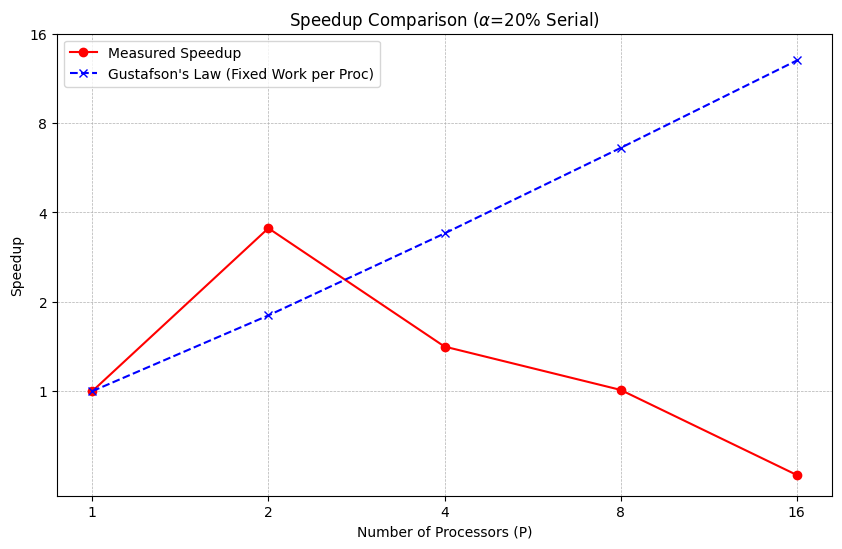

In [16]:
# Prepare data lists for plotting
P_list = list(plot_data.keys())
measured_speedups = [plot_data[P]['measured_we_mean'] for P in P_list]
gustafson_speedups = [plot_data[P]['theo_gustafson'] for P in P_list]

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Plot 1: Speedup Comparison
plt.plot(P_list, measured_speedups, 'o-', label='Measured Speedup', color='red')
plt.plot(P_list, gustafson_speedups, 'x--', label="Gustafson's Law (Fixed Work per Proc)", color='blue')

plt.title(f'Speedup Comparison ($\\alpha$={SERIAL_FRACTION*100:.0f}% Serial)')
plt.xlabel('Number of Processors (P)')
plt.ylabel('Speedup')
plt.yscale("log", base=2)
plt.xscale("log", base=2)
plt.xticks(P_values, [str(x) for x in P_values])
plt.yticks(P_values, [str(x) for x in P_values])
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()